### This code combines and pre-processes data from the copernicus climate data store (pre-downloaded)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.optimize
import scipy.stats
import scipy.interpolate
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from sklearn import tree
import copy
import calendar
#import seaborn as sns

import plotting
import dataset_fctns
import modelling_fctns
#from optimise_GDD_fctns import Phenology_set, run_GDD_and_get_RMSE, run_GDD_and_get_RMSE_derivs, plot_profiles_at_minimum, get_station_locations, put_ERA5_in_array
import seaborn as sns

import xarray as xr
from xarray.backends import NetCDF4DataStore
import cartopy.crs as ccrs
from scipy.interpolate import griddata
import numpy.ma as ma
from pyproj import Proj, transform
import rioxarray


#from dwd_phenpy import Phenology_set

#import openeo
#import ee
## Trigger the authentication flow.
#ee.Authenticate()#(auth_mode='localhost')
# Initialize the library.
#ee.Initialize(project='ee-martinparker637')

### First combine files downloaded as separate years

In [2]:
def combine_years(savename, first_year, last_year):
    ds = xr.open_dataset(f'C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\{savename}_{first_year}.nc')
    for year in range(first_year + 1, last_year + 1):
        print(year)
        ds = xr.concat([ds, xr.open_dataset(f'C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\{savename}_{year}.nc')], dim='valid_time')
    ds = ds.rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'})
    ds = ds.sortby('time')
    return ds

In [3]:
#ds = combine_years('\\Germany_Pre_2000\\t2m_d2m\\ERA5_t2m_d2m', 1991, 2000)
#ds = combine_years('ERA5_land',2001, 2024)
#ds_ssrd_tp = combine_years('\\Africa\\ssrd_tp\\ERA5_SSA_ssrd_tp', 1999, 2008)
ds = combine_years('\\Africa\\t2m_d2m\\ERA5_t2m_d2m_SSA', 1999, 2008)


2000
2001
2002
2003
2004
2005
2006
2007
2008


### Pre-process data

In [4]:
def vapor_pressure(T):
    return 6.1094*xr.ufuncs.exp((17.625*T)/(T + 243.04))# August–Roche–Magnus 
#Convert from K to C
ds['t2m'] += -273.15
ds['d2m'] += -273.15
#Calculate vapor pressures
sat_vp = 6.1094*xr.ufuncs.exp((17.625*ds['t2m'])/(ds['t2m'] + 243.04))
actual_vp = 6.1094*xr.ufuncs.exp((17.625*ds['d2m'])/(ds['d2m'] + 243.04))
#Combine to get VPD
ds['vpd'] = actual_vp - sat_vp #vapor_pressure(ds['d2m']) - vapor_pressure([ds['t2m']])
#t2m = ds['t2m'].resample(time="1D").mean()
#t2m.to_netcdf('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\Africa\\t2m_SSA_1999_2008.nc')
#t2max = ds['t2m'].resample(time="1D").max()
#t2max = t2max.rename('t2max')
#t2min = ds['t2m'].resample(time="1D").min()
#t2min = t2min.rename('t2min')
#ds_for_driver = xr.merge([t2m, t2max, t2min, ds['vpd']])
#ds_for_driver.to_netcdf('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\Germany_Pre_2000\\temp_vpd_DE_1991_2000.nc')


In [5]:
vpd = ds['vpd'].resample(time="1D").mean()

In [7]:
vpd.to_netcdf('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\Africa\\vpd_SSA_1999_2008_fixed.nc')
#vpd.to_netcdf('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\ERA5_DE_2001_2024_VPD_fixed.nc')
#ds['vpd'].to_netcdf('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\ERA5_DE_2001_2024_vpd.nc')

### Now pre-process other variables (daily averages)

In [5]:
ds = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\ERA5_land2_2011_2024.nc')

In [ ]:
ds_for_solrad = ds_ssrd_tp.where((ds_ssrd_tp['time.hour'] > 5)*(ds_ssrd_tp['time.hour'] < 19), drop=True)
ssrd = ds_for_solrad['ssrd'].resample(time="1D").mean()
tp = ds_ssrd_tp['tp'].resample(time="1D").sum()
ds_for_driver = xr.merge([ssrd, tp])
ds_for_driver.to_netcdf('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\Germany_Pre_2000\\ssrd_tp_DE_1991_1999.nc')

### Compare to higher resolution product to understand subgrid scale variation

In [2]:
hyras_data = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\tas_hyras_5_1951_2020_v5-0_de.nc').sel(time=slice('2000-01-01', '2020-12-31'))
hyras_data = hyras_data.drop(['x', 'y']).rename({'x': 'lon', 'y': 'lat'})
hyras_data= hyras_data.drop(['time_bnds', 'x_bnds', 'y_bnds'])
hyras_data= hyras_data.drop(['crs_HYRAS', 'number_of_stations'])
#hyras_data = hyras_data.rename({'y': 'lat', 'x': 'lon'})


C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_19336\1752857012.py:2: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  hyras_data = hyras_data.drop(['x', 'y']).rename({'x': 'lon', 'y': 'lat'})
C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_19336\1752857012.py:3: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  hyras_data= hyras_data.drop(['time_bnds', 'x_bnds', 'y_bnds'])
C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_19336\1752857012.py:4: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  hyras_data= hyras_data.drop(['crs_HYRAS', 'number_of_stations'])


In [3]:
#ERA5_data = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\AGERA5\\VPD\\AGERA5_VPD_DE_2000.nc')#.sel(time=slice('2000-01-01', '2024-12-31'))
ERA5_data = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\ERA5_land_2011_2024.nc')
ERA5_data = ERA5_data.rename({'latitude': 'lat', 'longitude': 'lon'})

In [7]:
#ERA5_data.isel(time=710)['Vapour_Pressure_Mean_24h'].values

In [3]:
import os
os.environ['PROJ_DATA'] = "C:\\ProgramData\\anaconda3\\envs\\Data_Analysis_Revived\\Lib\\site-packages\\rasterio\\proj_data"
xds = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\tas_hyras_5_1951_2020_v5-0_de.nc', decode_coords="all").sel(time=slice('2000-01-01', '2020-12-31'))
xds = xds.rio.write_crs("EPSG:3035")
xds = xds.drop(['lon', 'lat'])
xds_lonlat = xds.rio.reproject("EPSG:4326")

C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_24964\1201156179.py:5: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  xds = xds.drop(['lon', 'lat'])


In [ ]:
#ERA5_data['tas'] = hyras_data['tas'].interp(lat = ERA5_data['lat'], lon = ERA5_data['lon'])
ERA5_data['diff'] = ERA5_data['tas'] - ERA5_data['t2m']

In [4]:
hyras_data = hyras_data.where((hyras_data.time>np.datetime64('2012-01-01'))*(hyras_data.time<np.datetime64('2019-01-01')), drop = True)#dropna('time').mean(dim='time').plot()
ERA5_data = ERA5_data.where((ERA5_data.time>np.datetime64('2012-01-01'))*(ERA5_data.time<np.datetime64('2019-01-01')), drop = True)#dropna('time').mean(dim='time').plot()
hyras_data['time'] = hyras_data['time'] + np.timedelta64(-12, 'h')
hyras_data['t2m'] = ERA5_data['t2m'].interp(lat = hyras_data['lat'], lon = hyras_data['lon'])

In [9]:
#ERA5_data['t2m'].interp(lat = hyras_data['lat'], lon = hyras_data['lon']).mean(dim='time').plot()

In [54]:
print(ERA5_data.time.min().values,
        ERA5_data.time.max().values,
        hyras_data.time.min().values,
        hyras_data.time.max().values)


2012-01-02T00:00:00.000000000 2018-12-31T00:00:00.000000000 2012-01-01T00:00:00.000000000 2018-12-31T00:00:00.000000000


In [15]:
np.sqrt((hyras_data['diff']**2).mean(dim=['time', 'lat', 'lon'])).mean()

<xarray.DataArray 'diff' ()> Size: 8B
array(0.86501628)
Coordinates:
    number   int64 8B 0

(46.5, 55.0)

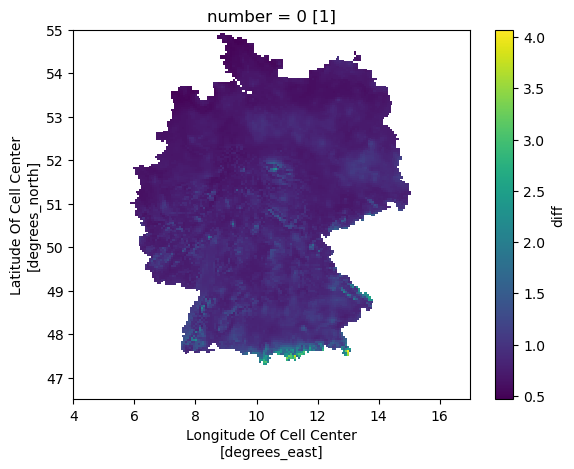

In [5]:
hyras_data['diff'] = hyras_data['tas'] - hyras_data['t2m']
fig, ax = plt.subplots()
#hyras_data['diff'].std(dim='time').plot(ax = ax)
np.sqrt((hyras_data['diff']**2).mean(dim='time')).plot(ax = ax)
ax.set_xlim((4, 17))
ax.set_ylim((46.5, 55))

In [63]:
hyras_data['diff'].std().values

array(0.855429)

In [7]:
ds_station = pd.read_table('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\produkt_tu_stunde_20091201_20191231_00071.txt',
                           sep=';')
ds_station['MESS_DATUM'] = pd.to_datetime(ds_station['MESS_DATUM'], format='%Y%m%d%H')
ds_station = ds_station.drop(columns=['eor'])
ds_station = ds_station.set_index('MESS_DATUM').resample('D').mean()#['TT_TU'].plot()
#ds_station.loc[:, 't2m'] = ERA5_data['t2m'].interp(lat = 48.2156, lon = 8.9784).resample(time='D').mean().values
ERA5_at_stat = ERA5_data['t2m'].interp(lat = 48.2156, lon = 8.9784).drop(['number', 'lat', 'lon']).to_dataframe()
#ERA5_at_stat.merge(ds_station, left_on='time', right_on='MESS_DATUM')
compare = ERA5_at_stat.join(ds_station)
compare.loc[:, 'diff'] = (compare['t2m'] - compare['TT_TU'])**2

C:\Users\wlwc1989\AppData\Local\Temp\ipykernel_19336\1716901907.py:7: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ERA5_at_stat = ERA5_data['t2m'].interp(lat = 48.2156, lon = 8.9784).drop(['number', 'lat', 'lon']).to_dataframe()


In [11]:
np.sqrt(compare['diff'].mean())

np.float64(1.1329812768001077)

In [9]:
compare.reset_index().groupby(compare.reset_index()['time'].dt.dayofyear).mean()['diff'].mean()#.plot()

np.float64(1.2908064768832985)

In [98]:
np.sqrt((compare['diff'].std()**2)*2)

np.float64(1.323965413647687)

In [99]:
#ds_station.groupby(ds_station['MESS_DATUM'].dt.day).mean()

In [100]:
#hyras_data['t2m'].mean(dim='time').plot()

(45.0, 52.0)

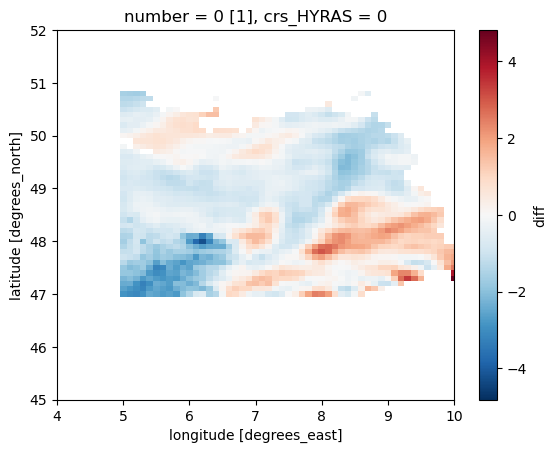

In [13]:
fig, ax = plt.subplots()
ERA5_data['diff'].mean(dim='time').plot(ax = ax)
ax.set_xlim((4, 10))
ax.set_ylim((45, 52))

In [20]:
import pyproj
pyproj.datadir.get_data_dir()#"C:\ProgramData\anaconda3\envs\Data_Analysis_Revived\Lib\site-packages\rasterio\proj_data\proj.db")

'C:\\ProgramData\\anaconda3\\envs\\Data_Analysis_Revived\\Library\\share\\proj'

In [ ]:
"C:\ProgramData\anaconda3\envs\Data_Analysis_Revived\Lib\site-packages\rasterio\proj_data\proj.db"

In [ ]:
"C:\ProgramData\anaconda3\envs\Data_Analysis_Revived\Library\share\proj\proj.db"

In [15]:
hyras_data.crs_HYRAS

<xarray.DataArray 'crs_HYRAS' ()> Size: 4B
array(1)
Attributes: (12/16)
    grid_mapping_name:                  lambert_conformal_conic
    long_name:                          DWD HYRAS ETRS89 LCC grid with 240 co...
    standard_parallel:                  [35. 65.]
    longitude_of_central_meridian:      10.0
    latitude_of_projection_origin:      52.0
    semi_major_axis:                    6378137.0
    ...                                 ...
    scale_factor_at_projection_origin:  0.017453292519943295
    proj4:                              +proj=lcc +lat_1=35 +lat_2=65 +lat_0=...
    proj4_params:                       +proj=lcc +lat_1=35 +lat_2=65 +lat_0=...
    epsg_code:                          EPSG:3034
    crs_wkt:                            PROJCS["ETRS_1989_LCC",GEOGCS["GCS_ET...
    spatial_ref:                        PROJCS["ETRS_1989_LCC",GEOGCS["GCS_ET...

In [18]:
hd = hyras_data['tas'].coarsen(lon=4).std().coarsen(lat=4).std()

c:\ProgramData\anaconda3\envs\Data_Analysis_Revived\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\ProgramData\anaconda3\envs\Data_Analysis_Revived\Lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [22]:
hd.isel(lon=25, lat = 25)

<xarray.DataArray 'tas' (time: 7671)> Size: 31kB
array([0.05299022, 0.06848152, 0.07651997, ..., 0.05393928, 0.06201186,
       0.06041406], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 61kB 2000-01-01T12:00:00 ... 2020-12-31T12...
    lon      float64 8B 10.15
    lat      float64 8B 50.23
Attributes:
    standard_name:      air_temperature
    long_name:          Daily Mean Air Temperature
    units:              Celsius
    grid_mapping:       crs_HYRAS
    cell_methods:       time: mean
    CoordinateSystems:  LatLonCoordinateSystem ProjectionCoordinateSystem
    esri_pe_string:     PROJCS["ETRS_1989_LCC",GEOGCS["GCS_ETRS_1989",DATUM["...

In [13]:
ERA5_data_t2m = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\ERA5_land_2020.nc')
ERA5_data_skin = xr.open_dataset('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\Saved_files\\ERA5\\Germany Skin\\ERA5_skin_DE_2020.nc')
ds_t2m = ERA5_data_t2m.rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'})
ds_skin = ERA5_data_skin.rename({'valid_time':'time', 'latitude':'lat', 'longitude':'lon'})
#ds = ds.sortby('time')
t2m = ds_t2m['t2m'].resample(time="1D").mean()
skin = ds_skin['skt'].resample(time="1D").mean()

In [74]:
np.sqrt(2*(0.8**2))

np.float64(1.1313708498984762)

In [27]:
0.8**2 + 1.1**2

1.8500000000000003

In [14]:
t2m['skt'] = skin

In [25]:
t2m['diff'] = (t2m.values - t2m['skt'])**2

In [26]:
np.sqrt(t2m['diff'].mean(dim=['time', 'lat', 'lon']))#.plot(vmax = 1, vmin = 0)#vmin = -1, vmax = 1, cmap = 'coolwarm')

<xarray.DataArray 'diff' ()> Size: 4B
array(0.85304284, dtype=float32)
Coordinates:
    number   int64 8B ...

In [56]:
skin = ds_skin['skt'].resample(time="1D").mean()

In [79]:
ERA5_data_t2m = ERA5_data_t2m.rename({'valid_time': 'time'})

In [80]:
tmax = ERA5_data_t2m['t2m'].resample(time="1D").max()
tmin = ERA5_data_t2m['t2m'].resample(time="1D").min()

In [84]:
diffmean = (tmax - tmin).std(dim = ['time', 'latitude', 'longitude'])

In [18]:
hyras_lon = hyras_data.lon.values
hyras_lat = hyras_data.lat.values
ERA5_lon = ERA5_data.lon.values
ERA5_lat = ERA5_data.lat.values
#hyras_LON, hyras_LAT = np.meshgrid(hyras_lon, hyras_lat)
ERA5_LON, ERA5_LAT = np.meshgrid(ERA5_lon, ERA5_lat)


In [45]:
ERA5_data['t2m mean'] = ERA5_data.t2m.mean(dim='time')
hyras_data['ERA5 t2m'] = (('time', 'lat', 'lon'), np.zeros(hyras_data.tas.values.shape))
interpolated_temps = []
for year in range(2011, 2020):
    if year % 4 == 0:
        numdays = 366
    else:
        numdays = 365
    for day in range(numdays):#366
        date = np.datetime64(f'{year}-01-01') + np.timedelta64(day, 'D')
        print(date)
        ERA5_interpolator = scipy.interpolate.RegularGridInterpolator((ERA5_lat, ERA5_lon), ERA5_data.t2m.sel(time=date).values, method='linear', bounds_error=False, fill_value=None)
        interpolated_temps.append(ERA5_interpolator((hyras_lat, hyras_lon)))

hyras_data['ERA5 t2m'] = (('time', 'lat', 'lon'), np.array(interpolated_temps))#ERA5_interpolator((hyras_lat, hyras_lon))#hyras_data.assign({'ERA5 t2m':(('lat', 'lon'), ERA5_interpolator((hyras_lat, hyras_lon)))})

2011-01-01
2011-01-02
2011-01-03
2011-01-04
2011-01-05
2011-01-06
2011-01-07
2011-01-08
2011-01-09
2011-01-10
2011-01-11
2011-01-12
2011-01-13
2011-01-14
2011-01-15
2011-01-16
2011-01-17
2011-01-18
2011-01-19
2011-01-20
2011-01-21
2011-01-22
2011-01-23
2011-01-24
2011-01-25
2011-01-26
2011-01-27
2011-01-28
2011-01-29
2011-01-30
2011-01-31
2011-02-01
2011-02-02
2011-02-03
2011-02-04
2011-02-05
2011-02-06
2011-02-07
2011-02-08
2011-02-09
2011-02-10
2011-02-11
2011-02-12
2011-02-13
2011-02-14
2011-02-15
2011-02-16
2011-02-17
2011-02-18
2011-02-19
2011-02-20
2011-02-21
2011-02-22
2011-02-23
2011-02-24
2011-02-25
2011-02-26
2011-02-27
2011-02-28
2011-03-01
2011-03-02
2011-03-03
2011-03-04
2011-03-05
2011-03-06
2011-03-07
2011-03-08
2011-03-09
2011-03-10
2011-03-11
2011-03-12
2011-03-13
2011-03-14
2011-03-15
2011-03-16
2011-03-17
2011-03-18
2011-03-19
2011-03-20
2011-03-21
2011-03-22
2011-03-23
2011-03-24
2011-03-25
2011-03-26
2011-03-27
2011-03-28
2011-03-29
2011-03-30
2011-03-31
2011-04-01

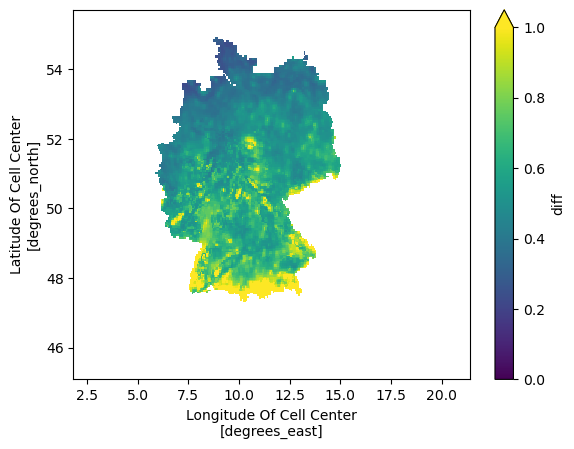

In [68]:
fig, ax = plt.subplots()
hyras_data['diff'].sel(time=slice('2000-01-01', '2020-12-31')).var(dim='time').plot(ax=ax, vmax = 1, vmin = 0)

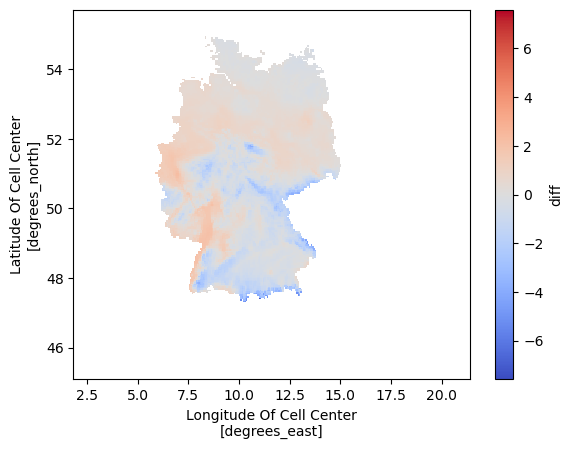

In [46]:
(meandiff - meandiff.mean()).plot(cmap = 'coolwarm')

### Evaluate varieties in DWD data

In [ ]:
ds_inputs_DE1 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_2001_2024.csv')
#ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]] = modelling_fctns.Wang_Engel_Temp_response(ds_inputs_DE.loc[:, [f'temperature at day {n}' for n in range(200)]], 7, 28, 42)
ds_inputs_DE1=ds_inputs_DE1.rename(columns={'Referenzjahr':'year'})
print(len(ds_inputs_DE1))
ds_inputs_DE1 = ds_inputs_DE1.dropna(how='all')
print(len(ds_inputs_DE1))
ds_inputs_DE1 = ds_inputs_DE1.loc[ds_inputs_DE1['observed time to beginning of flowering'] < 200]
ds_inputs_DE1 = ds_inputs_DE1.loc[ds_inputs_DE1['observed time to beginning of flowering'] > 40]
ds_inputs_DE2 = pd.read_csv('C:\\Users\\wlwc1989\\Documents\\Phenology_Test_Notebooks\\phenology_dwd\\results_for_comparing\\saved_ML_datasets\\DE_ML_ERA5_90s.csv')
ds_inputs_DE2=ds_inputs_DE2.rename(columns={'Referenzjahr':'year'})
ds_inputs_DE = pd.concat([ds_inputs_DE1, ds_inputs_DE2], ignore_index=True).drop_duplicates()
ds_inputs_DE = ds_inputs_DE.rename(columns = {f't2m at day {n}': f'temperature at day {n}' for n in range(300)})
ds_inputs_DE = ds_inputs_DE.rename(columns = {'year': 'Referenzjahr'})
ds_inputs_DE['observed time to beginning of flowering'] = pd.to_timedelta(ds_inputs_DE['observed time to beginning of flowering'], 'D')#, 'D'
FAO_sorts_string = ds_inputs_DE['SORTE'].str.split(' ').str.get(-1)
FAO_sorts_string = FAO_sorts_string*(1 - FAO_sorts_string.str.contains(r'[a-zA-Z]', regex=True))
FAO_sorts_string.replace('', np.nan, inplace = True)
FAO_sorts_string.fillna(0, inplace=True)
FAO_sorts_string = FAO_sorts_string.astype(np.int64)
ds_inputs_DE['FAO_sort'] = FAO_sorts_string
ds_inputs_DE['FAO_sort'].unique()
print(len(ds_inputs_DE['FAO_sort']), len(ds_inputs_DE['FAO_sort'].dropna()))
ds_inputs_DE.loc[ds_inputs_DE['FAO_sort'] == 0, 'FAO_sort'] = (ds_inputs_DE.loc[ds_inputs_DE['FAO_sort'] == 0, 'SILOREIFEZAHL'] + ds_inputs_DE.loc[ds_inputs_DE['FAO_sort'] == 0, 'KOERNERREIFEZAHL'])/2
early_threshold = 220
ei_threshold = 225
il_threshold = 250
ds_inputs_DE_early = ds_inputs_DE.loc[(ds_inputs_DE['FAO_sort'] > 0)*(ds_inputs_DE['FAO_sort'] < early_threshold)]
print(len(ds_inputs_DE_early))
ds_inputs_DE_ei = ds_inputs_DE.loc[(ds_inputs_DE['FAO_sort'] >= early_threshold)*(ds_inputs_DE['FAO_sort'] <= ei_threshold)]
print(len(ds_inputs_DE_ei))
ds_inputs_DE_il = ds_inputs_DE.loc[(ds_inputs_DE['FAO_sort'] > ei_threshold)*(ds_inputs_DE['FAO_sort'] < il_threshold)]
print(len(ds_inputs_DE_il))
ds_inputs_DE_late = ds_inputs_DE.loc[(ds_inputs_DE['FAO_sort'] >= il_threshold)]
print(len(ds_inputs_DE_late))

15308
15308
26208 26208
2803
3492
4434
3161


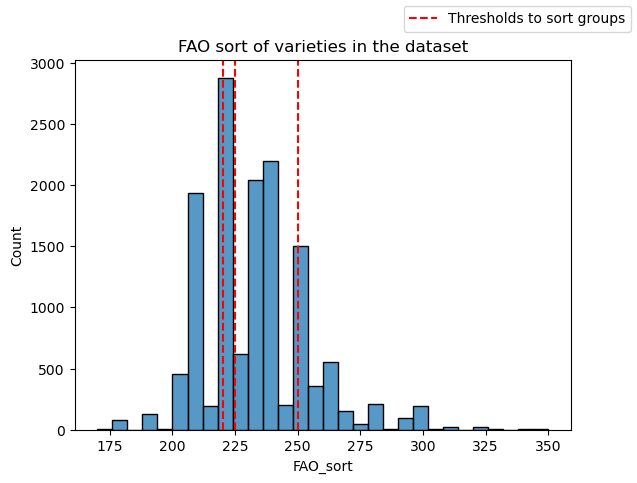

In [39]:
fig, ax = plt.subplots()
sns.histplot(ds_inputs_DE['FAO_sort'], ax = ax, bins = 30)
ax.set_title('FAO sort of varieties in the dataset')
ax.axvline(early_threshold, color = 'red', linestyle = '--', label = 'Thresholds to sort groups')
ax.axvline(ei_threshold, color = 'red', linestyle = '--')
ax.axvline(il_threshold, color = 'red', linestyle = '--')
fig.legend()

In [ ]:
ds_inputs_DE_early.loc[:, 'sort bin'] = 'Early'
ds_inputs_DE_ei.loc[:, 'sort bin'] = 'Early-intermediate'
ds_inputs_DE_il.loc[:, 'sort bin'] = 'Intermediate-late'
ds_inputs_DE_late.loc[:, 'sort bin'] = 'Late'
ds_inputs_DE_named = pd.concat([ds_inputs_DE_early, ds_inputs_DE_ei, ds_inputs_DE_il, ds_inputs_DE_late], ignore_index=True)

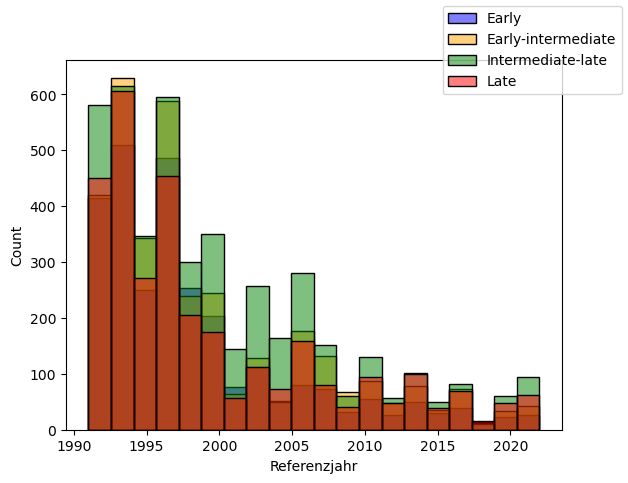

In [5]:
fig, ax = plt.subplots()
sns.histplot(ds_inputs_DE_early['Referenzjahr'], ax=ax, bins=20, color='blue', label='Early', alpha=0.5)
sns.histplot(ds_inputs_DE_ei['Referenzjahr'], ax=ax, bins=20, color='orange', label='Early-intermediate', alpha=0.5)
sns.histplot(ds_inputs_DE_il['Referenzjahr'], ax=ax, bins=20, color='green', label='Intermediate-late', alpha=0.5)
sns.histplot(ds_inputs_DE_late['Referenzjahr'], ax=ax, bins=20, color='red', label='Late', alpha=0.5)
fig.legend(loc='upper right')